In [1]:
#impot libraries and packeges
import io
import os
import cv2 
import PIL.Image
import pytesseract
import numpy as np
from pytesseract import Output
from matplotlib import pyplot as plt
from IPython.display import clear_output, Image, display

In [2]:
#defining the image path
pytesseract.pytesseract.tesseract_cmd = 'C:/Program Files/Tesseract-OCR/tesseract.exe'
IMG_DIR = 'dataset/'

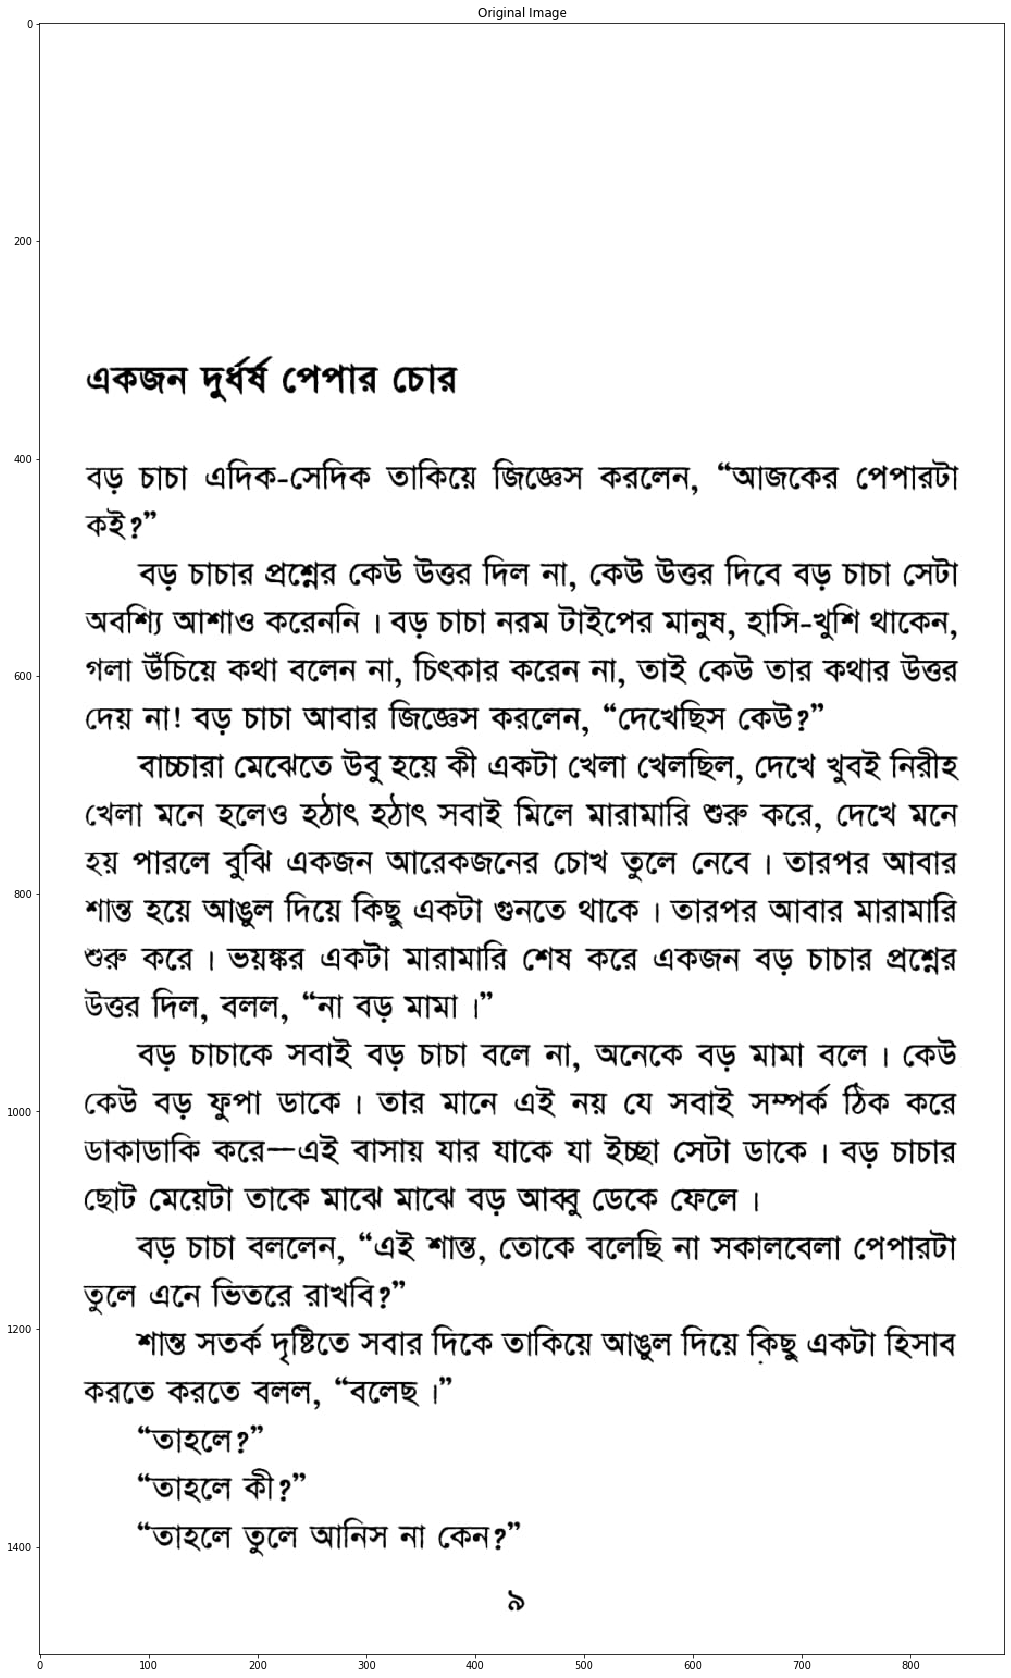

In [3]:
#taking input
image = cv2.imread(IMG_DIR + 'img1.jpg')

plt.figure(figsize=(30,30))
plt.title('Original Image')
plt.imshow(image)
plt.show()

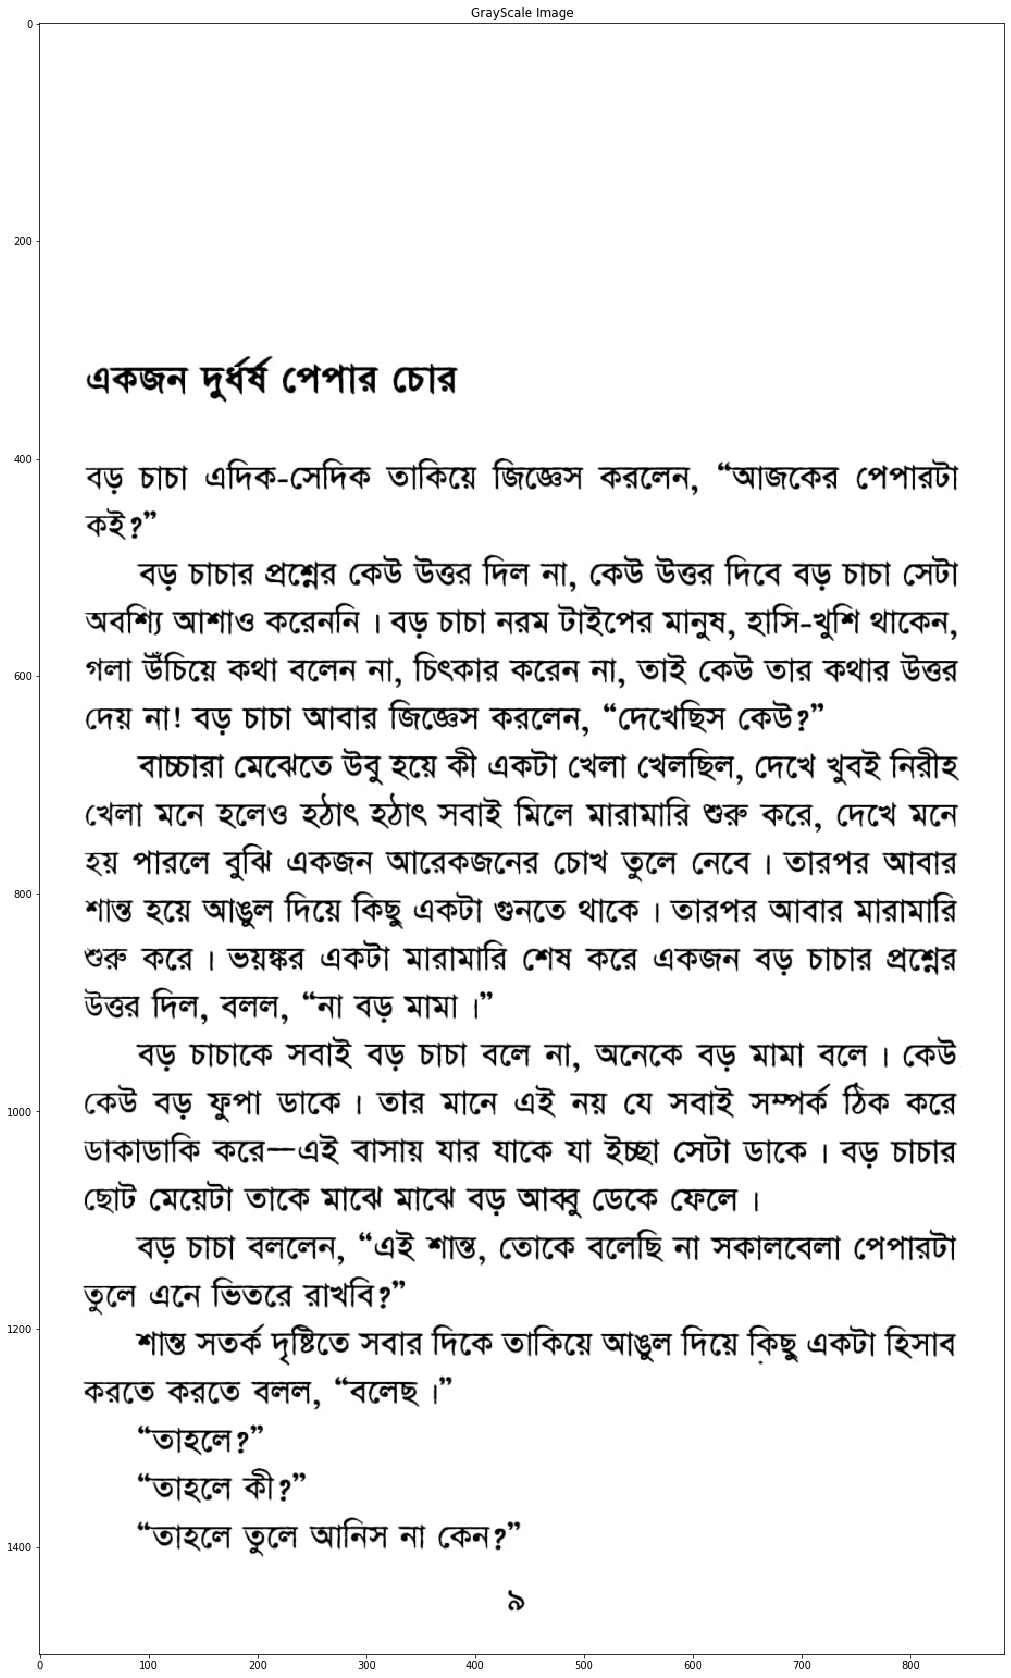

In [4]:
#applying greyscale filter
gray_scale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(30,30))
plt.title('GrayScale Image')
plt.imshow(gray_scale_image, cmap='gray')
plt.show()

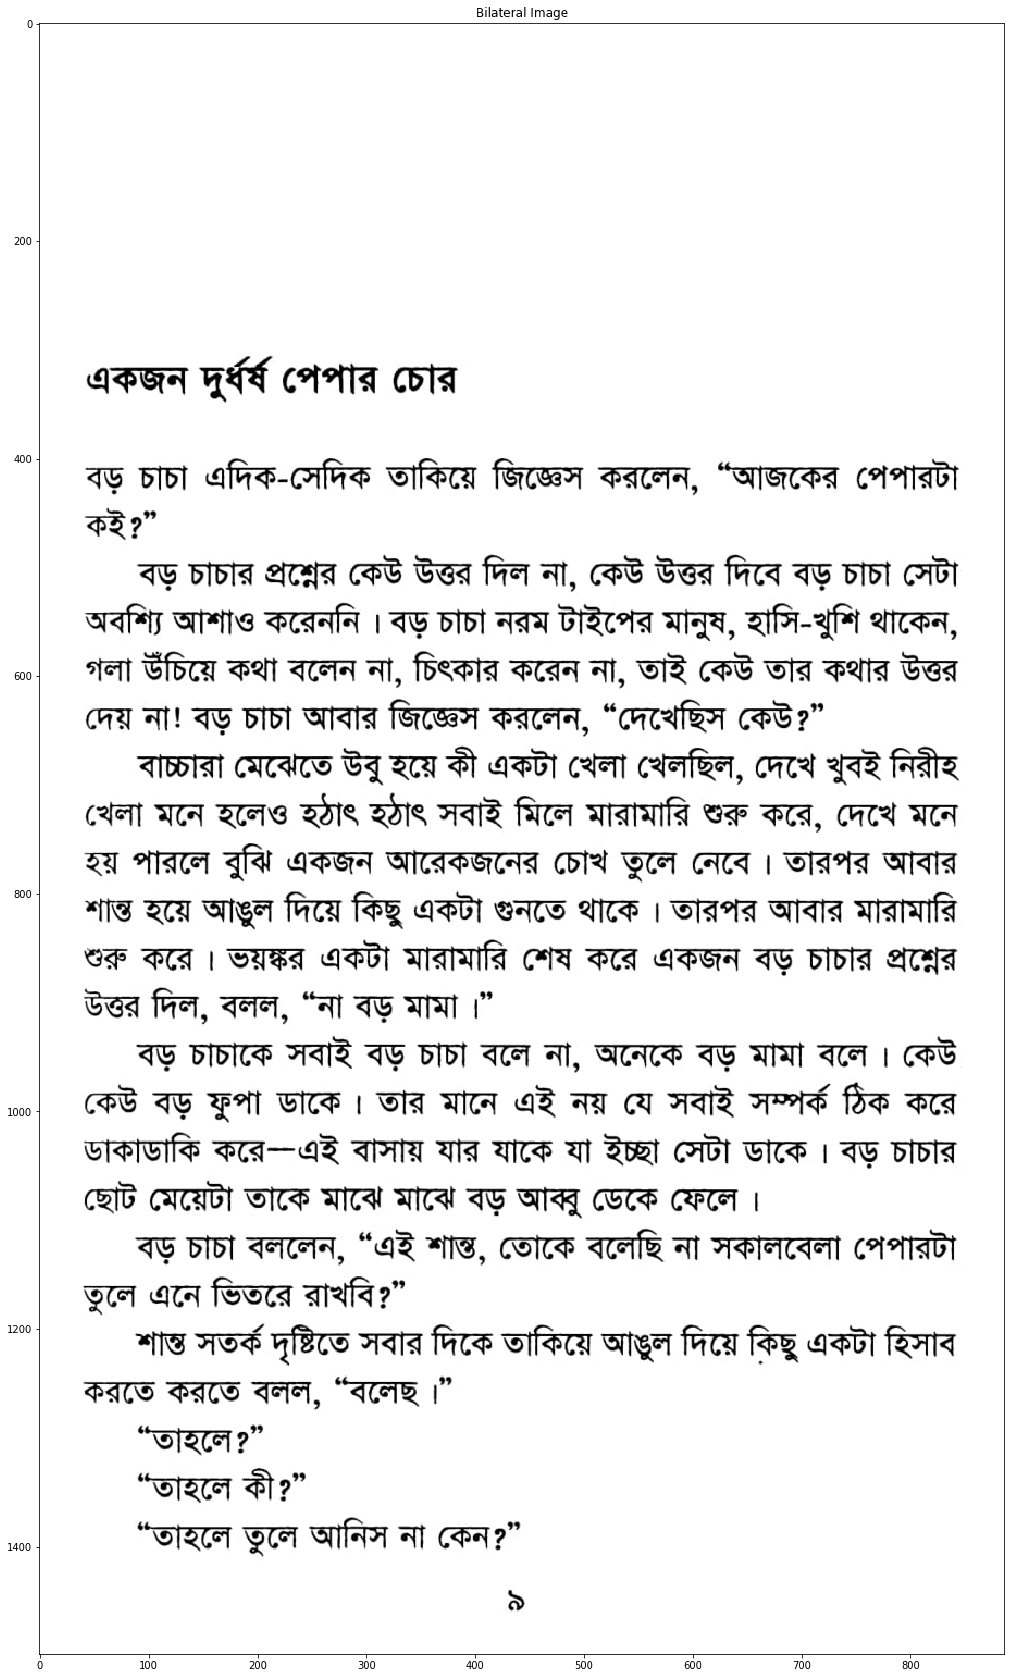

In [5]:
#applying bilateral filter
bilateral_image = cv2.bilateralFilter(gray_scale_image, 15, 75, 75)

plt.figure(figsize=(30,30))
plt.title('Bilateral Image')
plt.imshow(gray_scale_image, cmap='gray')
plt.show()

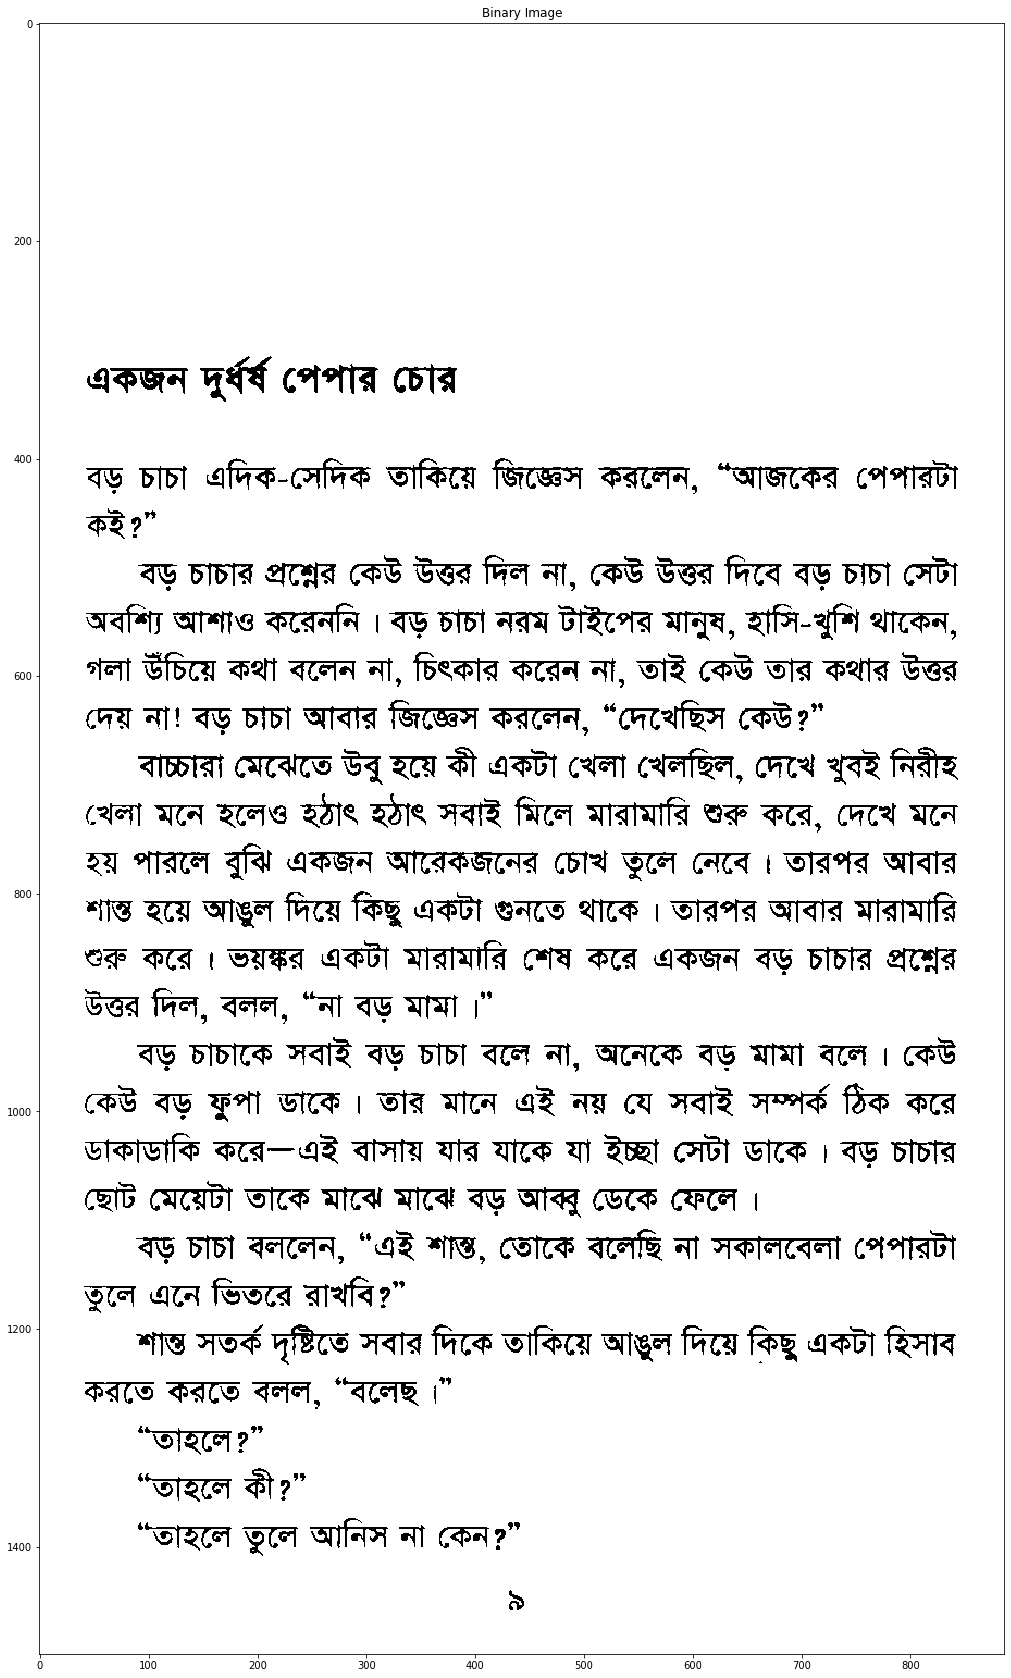

In [6]:
#applying bit plane slicing or getting binary image
binary_image = cv2.bitwise_not(bilateral_image)
thresh = cv2.threshold(bilateral_image, 0, 255,
	cv2.THRESH_OTSU)[1]

plt.figure(figsize=(30,30))
plt.title('Binary Image')
plt.imshow(thresh, cmap = "gray")
plt.show()

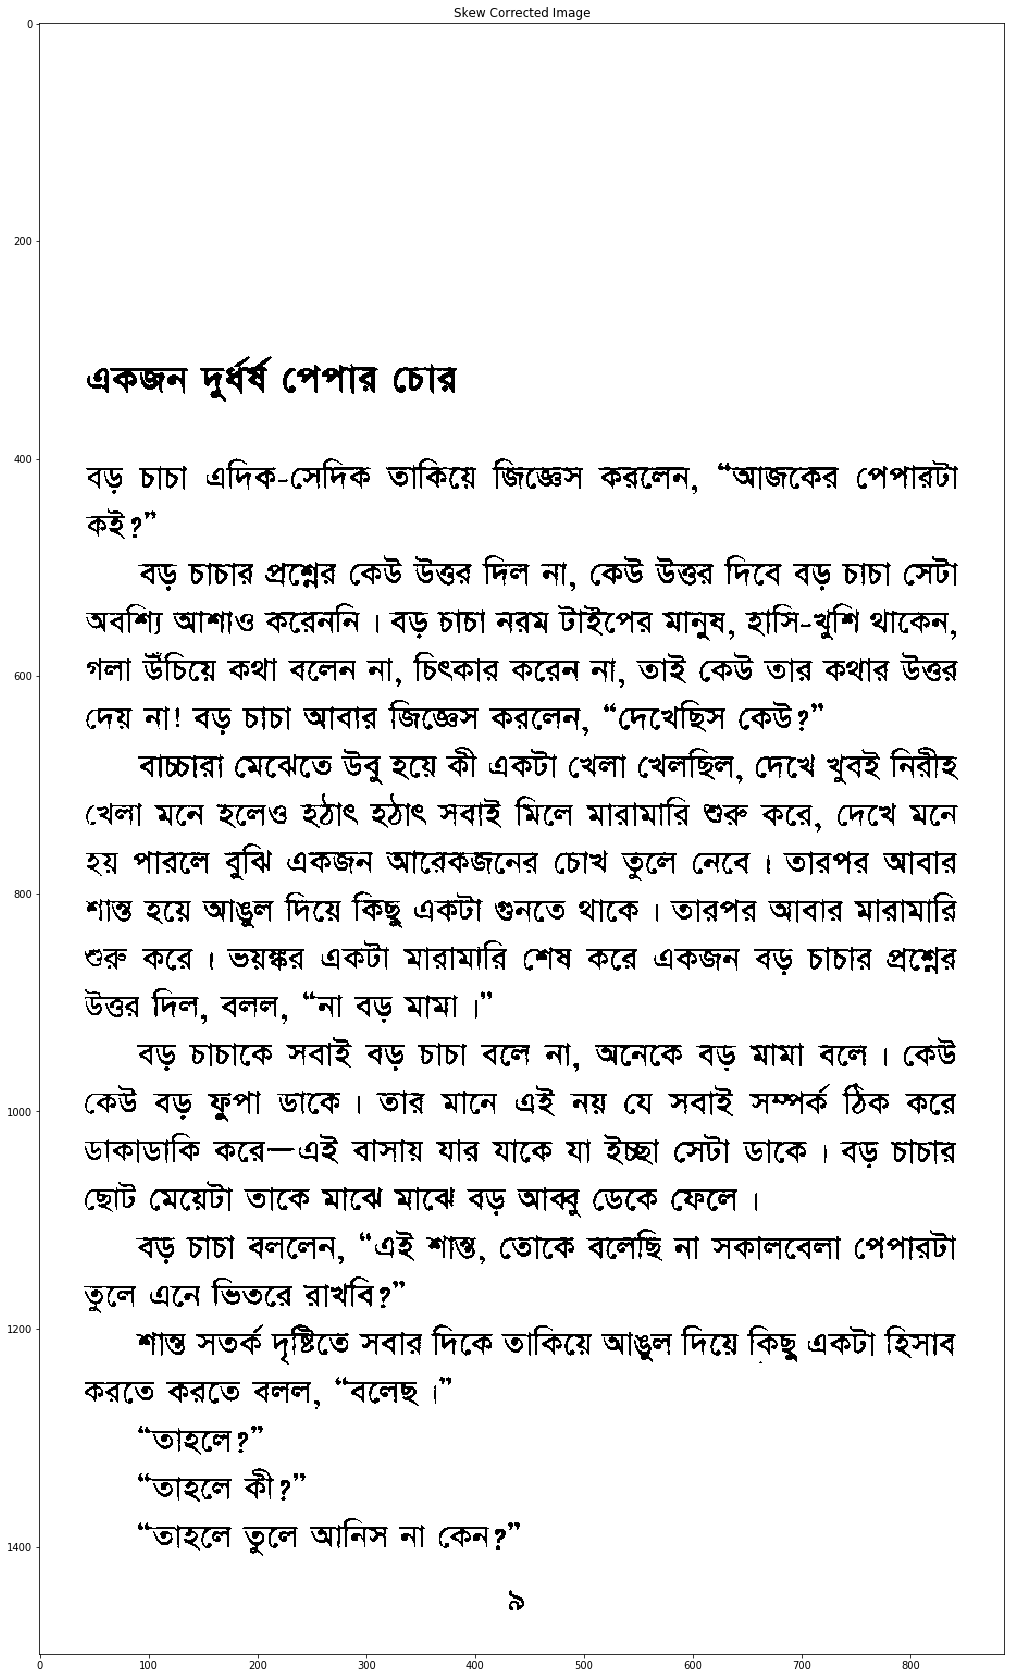

In [7]:
#applying skew angle correction
coords = np.column_stack(np.where(thresh > 0))
angle = cv2.minAreaRect(coords)[-1]
if angle < -45:
	angle = -(90 + angle)
else:
	angle = -angle
(h, w) = binary_image.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, angle, 1.0)
rotated_image = cv2.warpAffine(thresh, M, (w, h))

plt.figure(figsize=(30,30))
plt.title('Skew Corrected Image')
plt.imshow(rotated_image, cmap = "gray")
plt.show()

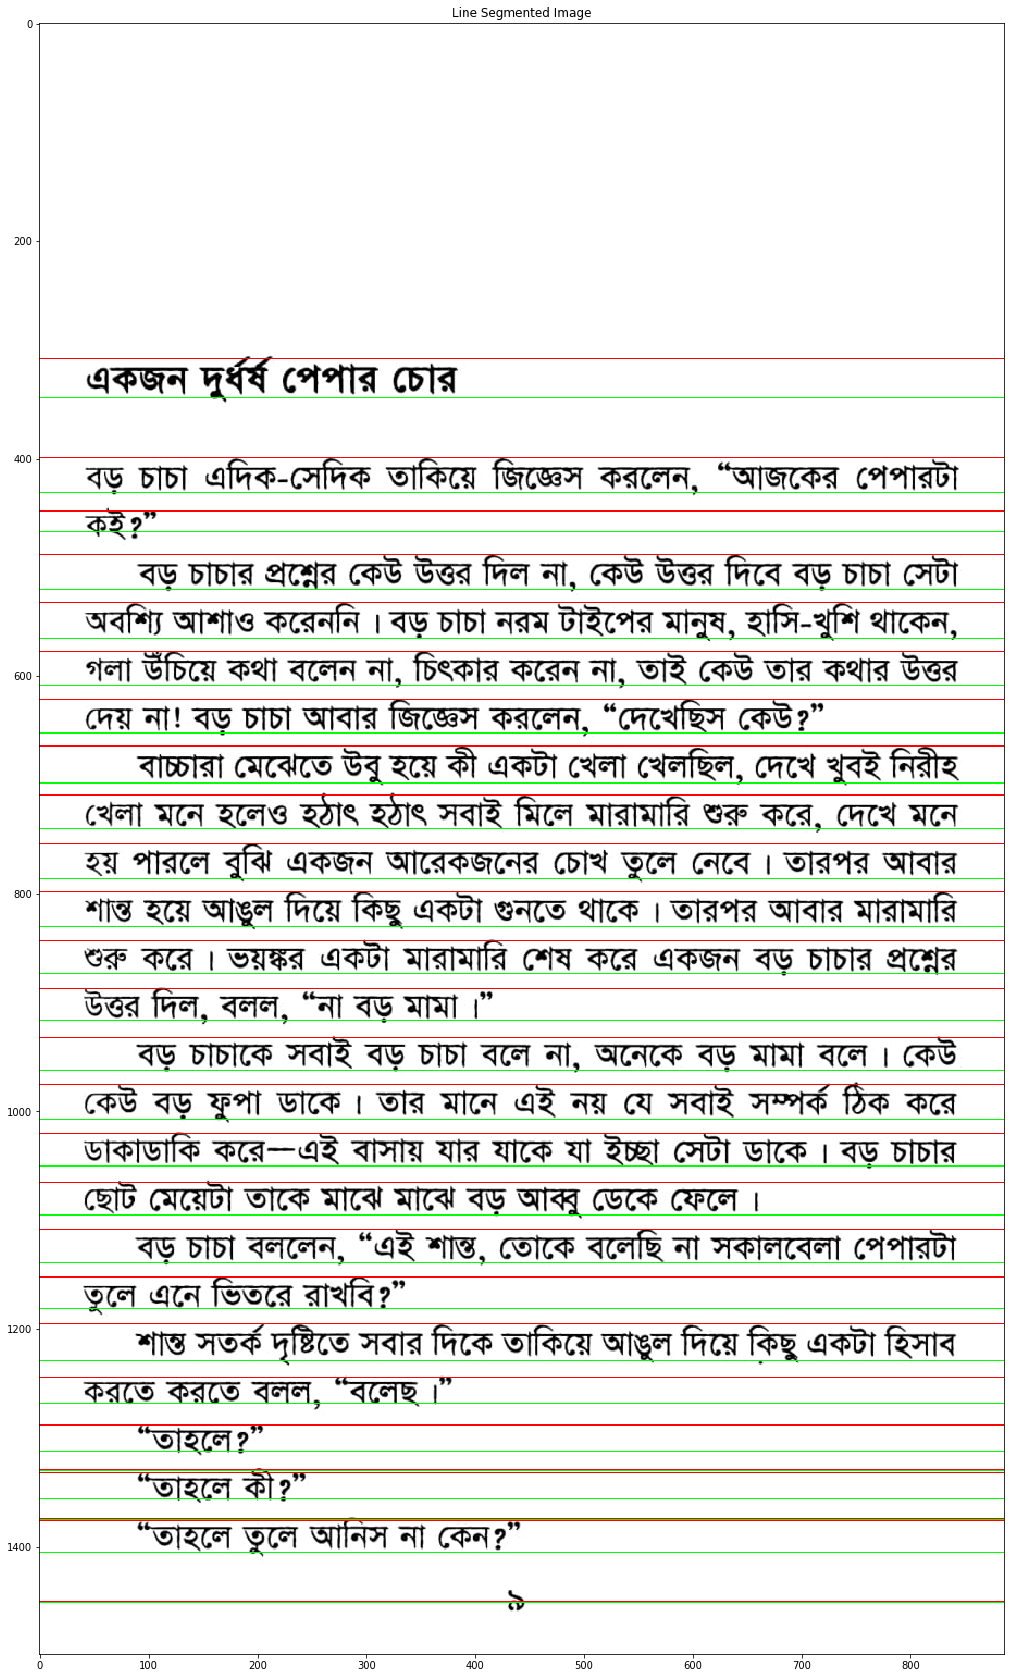

In [8]:
hist = cv2.reduce(binary_image,1, cv2.REDUCE_AVG).reshape(-1)

th = 2
H,W = gray_scale_image.shape[:2]
uppers = [y for y in range(H-1) if hist[y]<=th and hist[y+1]>th]
lowers = [y for y in range(H-1) if hist[y]>th and hist[y+1]<=th]

binary_image = cv2.cvtColor(gray_scale_image, cv2.COLOR_GRAY2BGR)
for y in uppers:
    cv2.line(binary_image, (0,y), (W, y), (255,0,0), 1)

for y in lowers:
    cv2.line(binary_image, (0,y), (W, y), (0,255,0), 1)
    
plt.figure(figsize=(30,30))
plt.title('Line Segmented Image')
plt.imshow(binary_image)
plt.show()

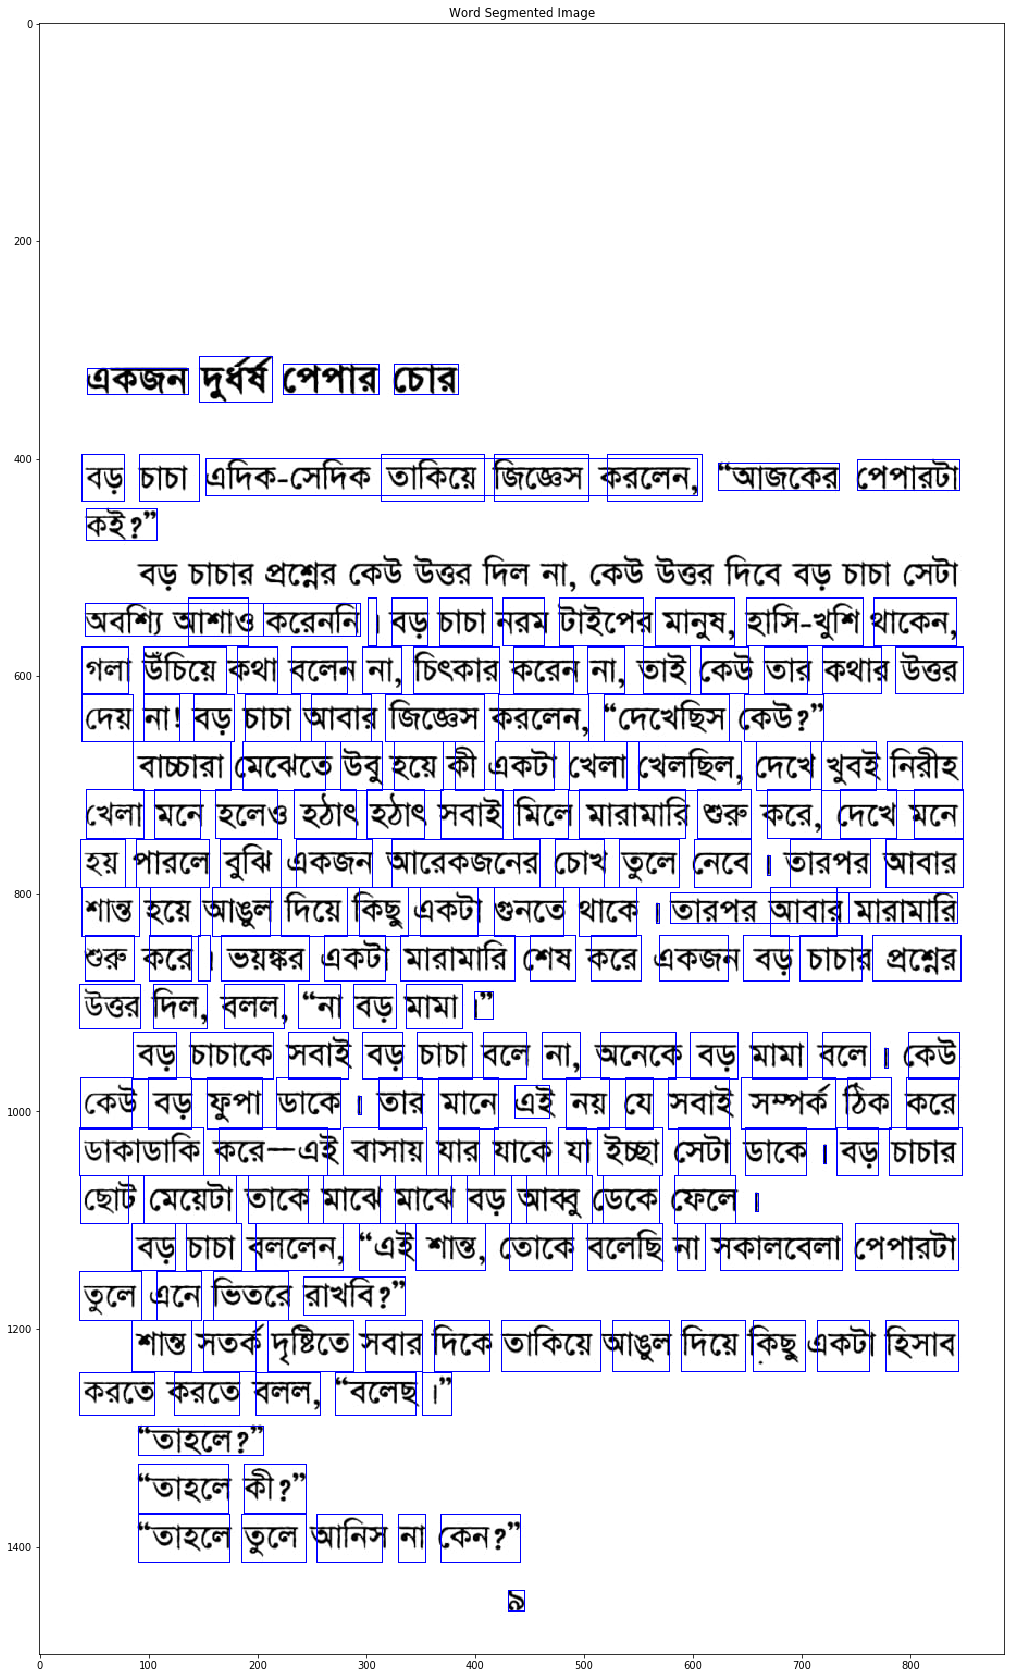

In [9]:
d = pytesseract.image_to_data(gray_scale_image, output_type=Output.DICT,lang="ben")
image = cv2.imread(IMG_DIR + 'img1.jpg')
n_boxes = len(d['text'])
for i in range(n_boxes):
    if int(d['conf'][i]) > 0:
        (x, y, w, h) = (d['left'][i], d['top'][i], d['width'][i], d['height'][i])
        image = cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 1)


plt.figure(figsize=(30,30))
plt.imshow(image)
plt.title('Word Segmented Image')
plt.show()

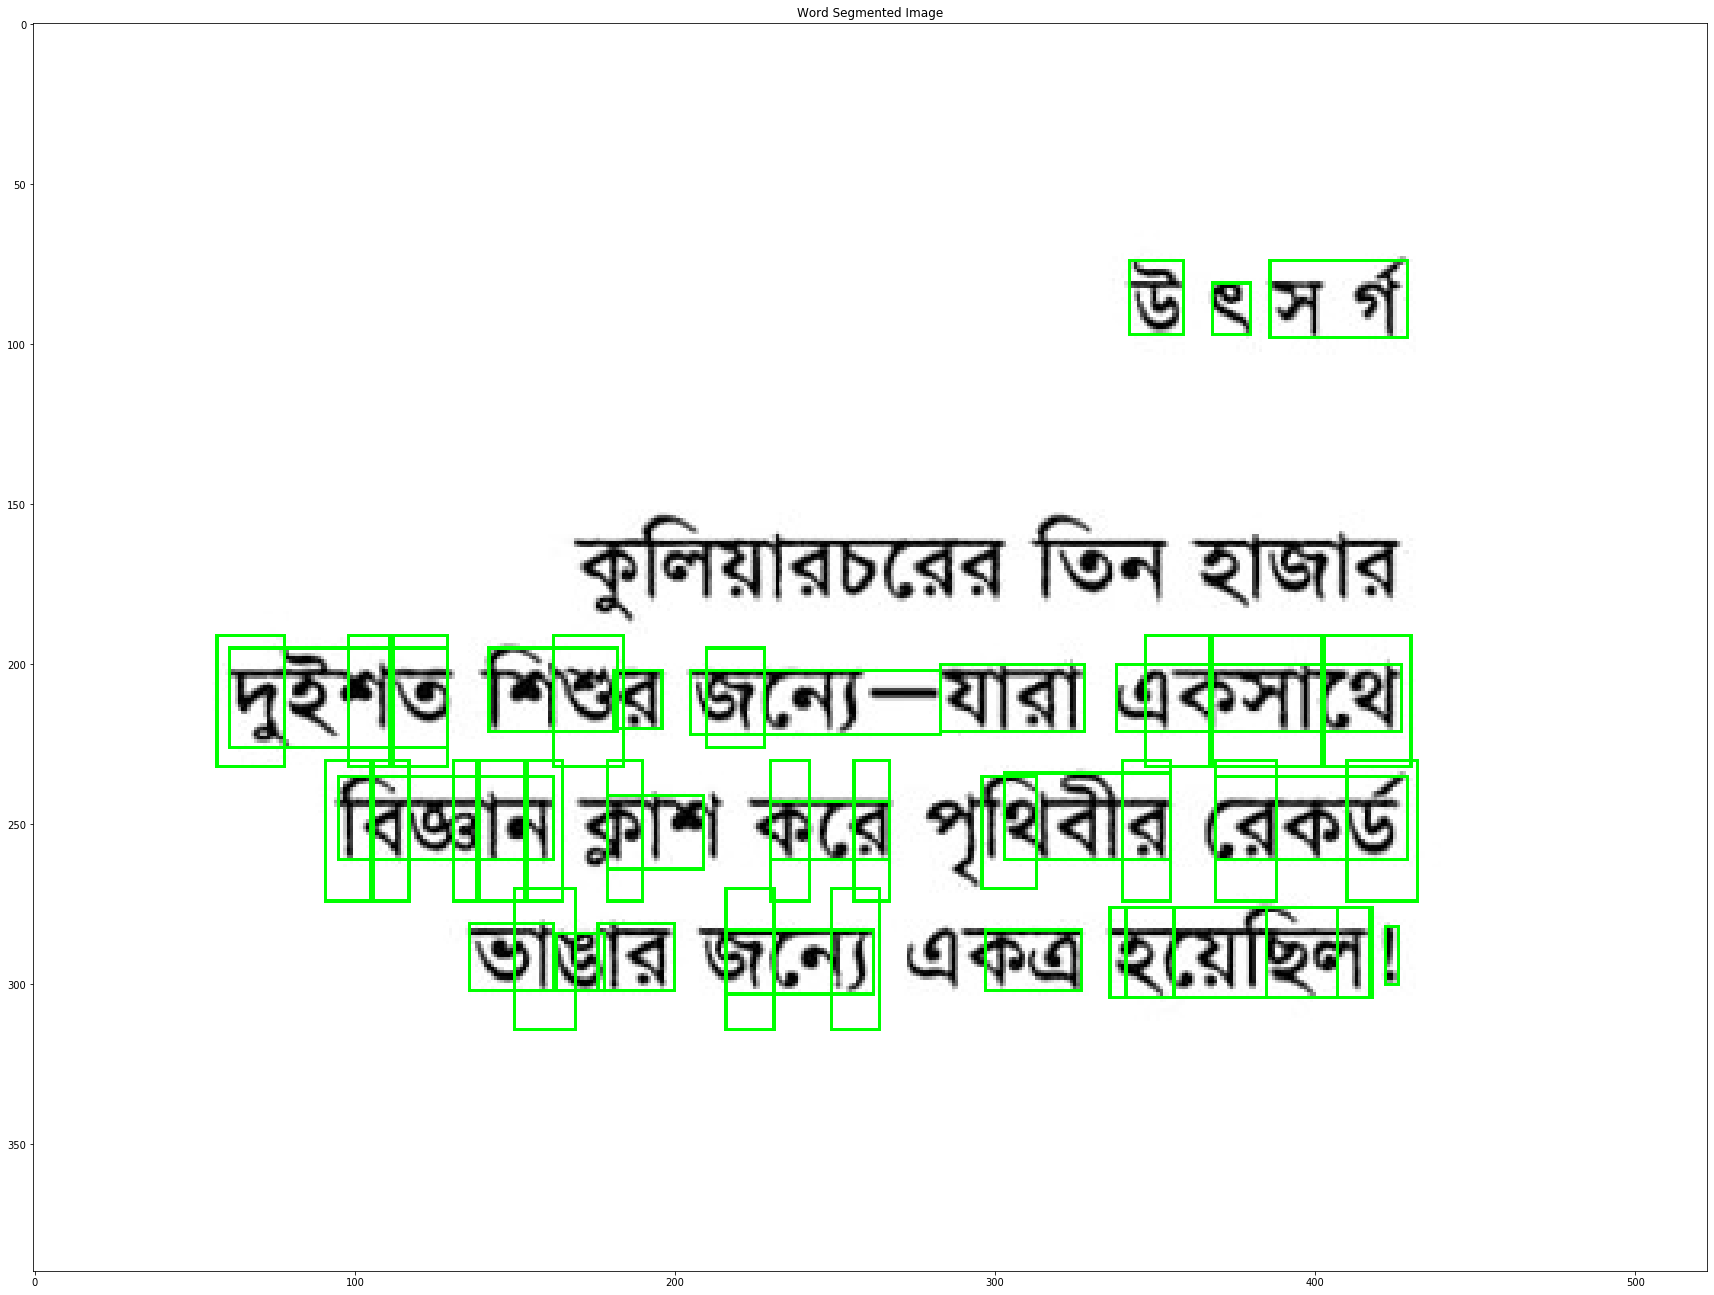

In [75]:
image = cv2.imread(IMG_DIR + 'img65.jpg')
h, w, c = image.shape
boxes = pytesseract.image_to_boxes(image) 
for b in boxes.splitlines():
    b = b.split(' ')
    image = cv2.rectangle(image, (int(b[1]), h - int(b[2])), (int(b[3]), h - int(b[4])), (0, 255, 0), 1)

plt.figure(figsize=(30,30))
plt.imshow(image)
plt.title('Word Segmented Image')
plt.show()

In [11]:
print("\n!!!! Extracted Text !!!!\n")
text = pytesseract.image_to_string(gray_scale_image,lang="ben")
print (text)


!!!! Extracted Text !!!!

একজন দুর্ধর্ষ পেপার চোর

বড় চাচা এদিক-সেদিক তাকিয়ে জিজ্ঞেস করলেন, “আজকের পেপারটা
কই?”
অবশ্যি আশাও করেননি | বড় চাচা নরম টাইপের মানুষ, হাসি-খুশি থাকেন,
গলা উচিয়ে কথা বলেন না, চিৎকার করেন না, তাই কেউ তার কথার উত্তর
দেয় না! বড় চাচা আবার জিজ্ঞেস করলেন, “দেখেছিস কেউ?”

বাচ্চারা মেঝেতে উবু হয়ে কী একটা খেলা খেলছিল, দেখে খুবই নিরীহ
খেলা মনে হলেও হঠাৎ হঠাৎ সবাই মিলে মারামারি শুরু করে, দেখে মনে
হয় পারলে বুঝি একজন আরেকজনের চোখ তুলে নেবে । তারপর আবার
শান্ত হয়ে আঙুল দিয়ে কিছু একটা গুনতে থাকে । তারপর আবার মারামারি
শুরু করে । ভয়ঙ্কর একটা মারামারি শেষ করে একজন বড় চাচার প্রশ্নের
উত্তর দিল, বলল, “না বড় মামা ।”

বড় চাচাকে সবাই বড় চাচা বলে না, অনেকে বড় মামা বলে । কেউ
কেউ বড় ফুপা ডাকে । তার মানে এই নয় যে সবাই সম্পর্ক ঠিক করে
ডাকাডাকি করে--এই বাসায় যার যাকে যা ইচ্ছা সেটা ডাকে । বড় চাচার
ছোট মেয়েটা তাকে মাঝে মাঝে বড় আব্বু ডেকে ফেলে ।

বড় চাচা বললেন, “এই শান্ত, তোকে বলেছি না সকালবেলা পেপারটা
তুলে এনে ভিতরে রাখবি?”

শান্ত সতর্ক দৃষ্টিতে সবার দিকে তাকিয়ে আঙুল দি